In [1]:
import sys
sys.path.append('../../Python_scripts')

In [2]:
## Import packages
from config import *
from support import *
from cosmo_support import *

## Plotting
plt.rcParams['font.family'] ='Times New Roman'
plt.rcParams['mathtext.fontset'] = 'dejavuserif'

/home/zhuge/miniconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [3]:
def mcmc_plot_results(samples, param_names, truths, savetitle=None, bins=30, target_prob=0.6827, font_size=15):
    """
    Plot the MCMC results.
    
    Args:
        samples: MCMC samples
        param_names: Names of the parameters
    """
    
    # Create corner plot
    
    fig = corner.corner(
        samples, 
        labels=param_names,
        truths=truths,
        truth_color='tab:orange',
        quantiles=[0.5-target_prob/2, 0.5, 0.5+target_prob/2], ### [0.16, 0.5, 0.84],
        q_ls=['--', ' ', '--'],
        show_titles=True,
        title_kwargs={"fontsize": font_size-2},
        label_kwargs={"fontsize": font_size},
        title_fmt='.3f',
        bins=bins,
        smooth=True,
        color='tab:blue'
    )

    for ax in fig.get_axes():
        ax.tick_params(axis='both', labelsize=font_size)
    
    if savetitle is not None:
        plt.savefig(savetitle+"_corner_plot.pdf", dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

for DM_diff one

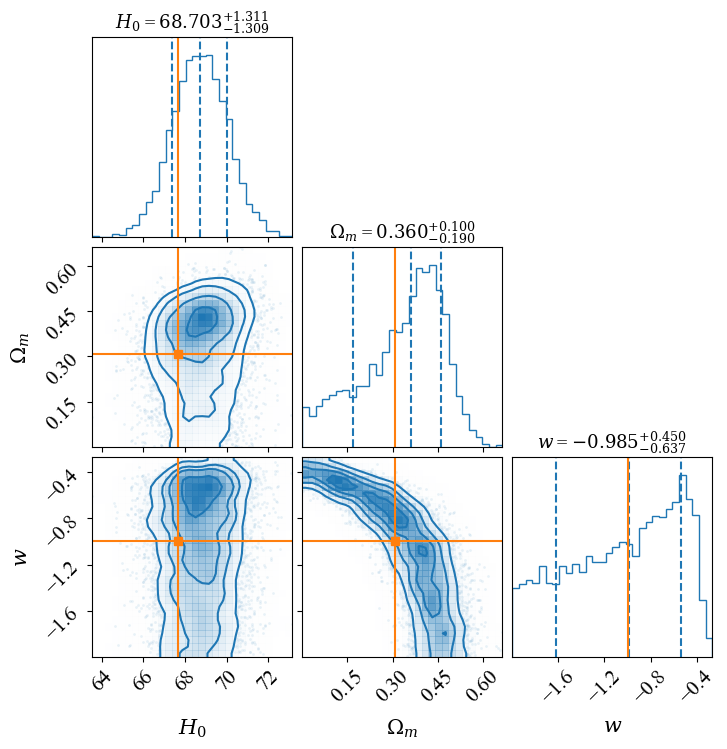

In [4]:
posterior_diff = np.load('posterior/MCMC_DM_diff_2.npy')
param_names_diff = [r'$H_0$', r'$\Omega_m$', r'$w$']
truth_diff=[HUBBLE, OMEGA_MATTER, W_LAMBDA]
mcmc_plot_results(posterior_diff, param_names_diff, truth_diff, bins=30, target_prob=0.6827)

for DM_ext one

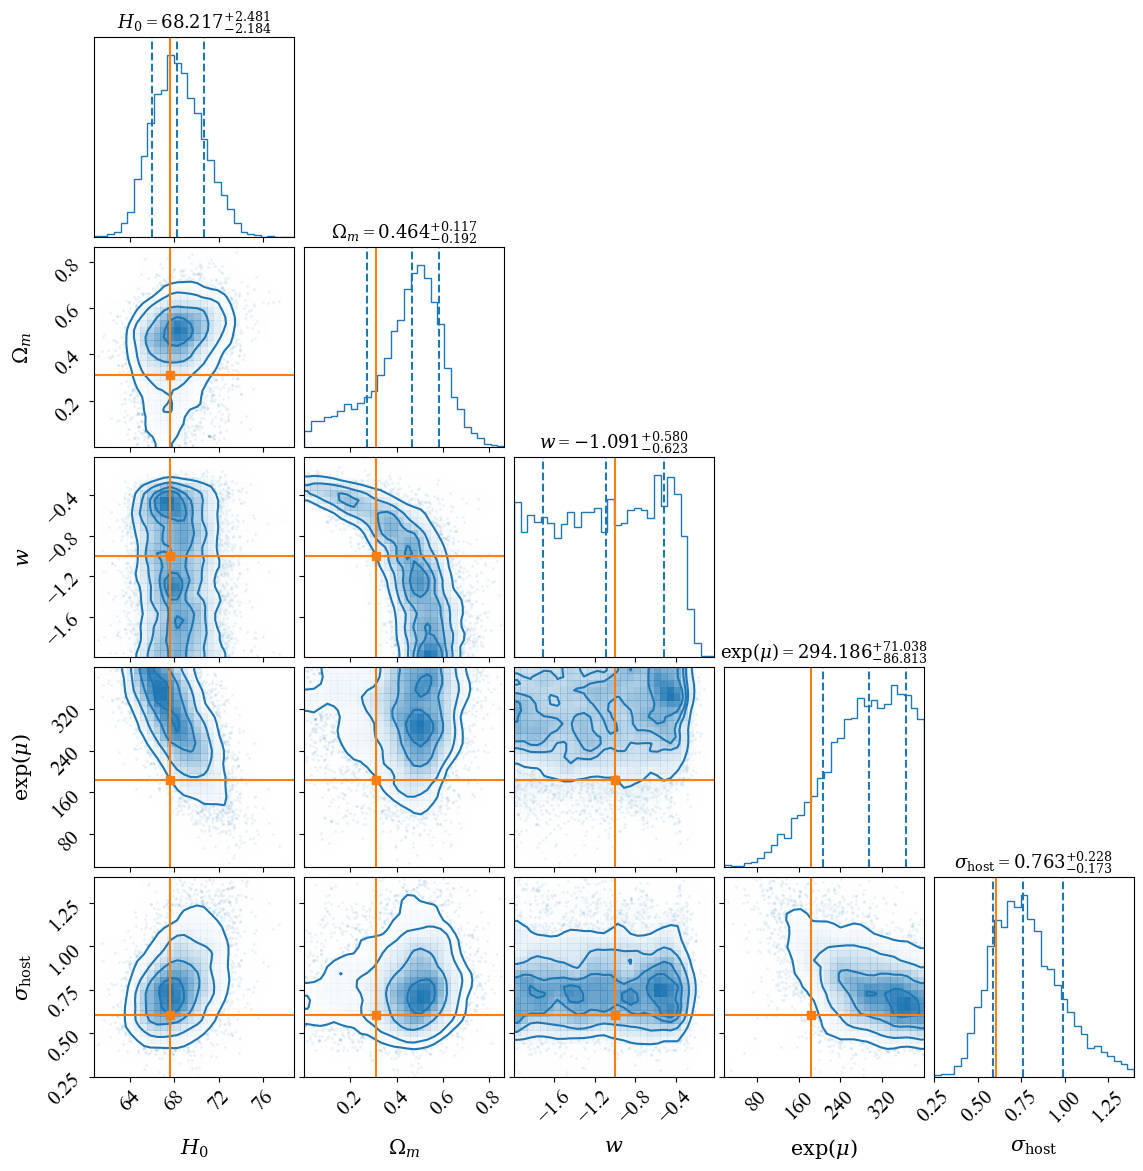

In [5]:
posterior_ext = np.load('posterior/MCMC_DM_ext_2.npy')
param_names_ext = [r'$H_0$', r'$\Omega_m$', r'$w$', r'$\exp(\mu)$', r'$\sigma_{\rm host}$']
truth_ext=[HUBBLE, OMEGA_MATTER, W_LAMBDA, 182.937, 0.605]
mcmc_plot_results(posterior_ext, param_names_ext, truth_ext, bins=30, target_prob=0.6827)

## Comparison plots

In [6]:
# low redshift (z<0.2), all log-normal PDF
lowz_diff_CE = np.load('./posterior/MCMC_DM_diff_02_CE.npy')
lowz_diff_LV = np.load('./posterior/MCMC_DM_diff_02_LVK.npy')
lowz_ext_CE = np.load('./posterior/MCMC_DM_ext_02_CE.npy')
lowz_ext_LV = np.load('./posterior/MCMC_DM_ext_02_LVK.npy')

# high redshift (0.2<z<2), all CE
highz_diff = np.load('./posterior/MCMC_DM_diff_2.npy')
highz_ext = np.load('./posterior/MCMC_DM_ext_2.npy')
highz_diff_ln = np.load('./posterior/MCMC_DM_diff_2_ln.npy')
highz_ext_ln = np.load('./posterior/MCMC_DM_ext_2_ln.npy')

**Low-z -- CE vs LV**

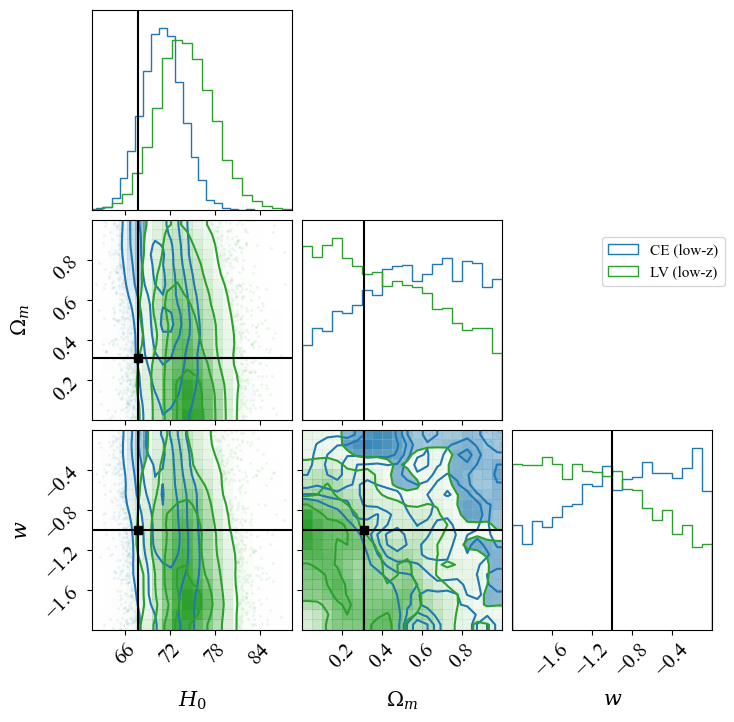

In [7]:
labels = [r"$H_0$", r"$\Omega_m$", r"$w$"]

fig = corner.corner(
    lowz_diff_CE, labels=labels, color="tab:blue", smooth=True, label_kwargs={"fontsize": 15},
)
corner.corner(
    lowz_diff_LV, fig=fig, truths=[HUBBLE, OMEGA_MATTER, W_LAMBDA], truth_color='black', color="tab:green", smooth=True
);

for ax in fig.get_axes():
    ax.tick_params(axis='both', labelsize=15)

plt.legend(['CE (low-z)', 'LV (low-z)'], loc='upper right', bbox_to_anchor=(0.1, 1., 1, 1), fontsize=11)
plt.savefig('./figures/MCMC_DM_diff_02.pdf')
plt.show()

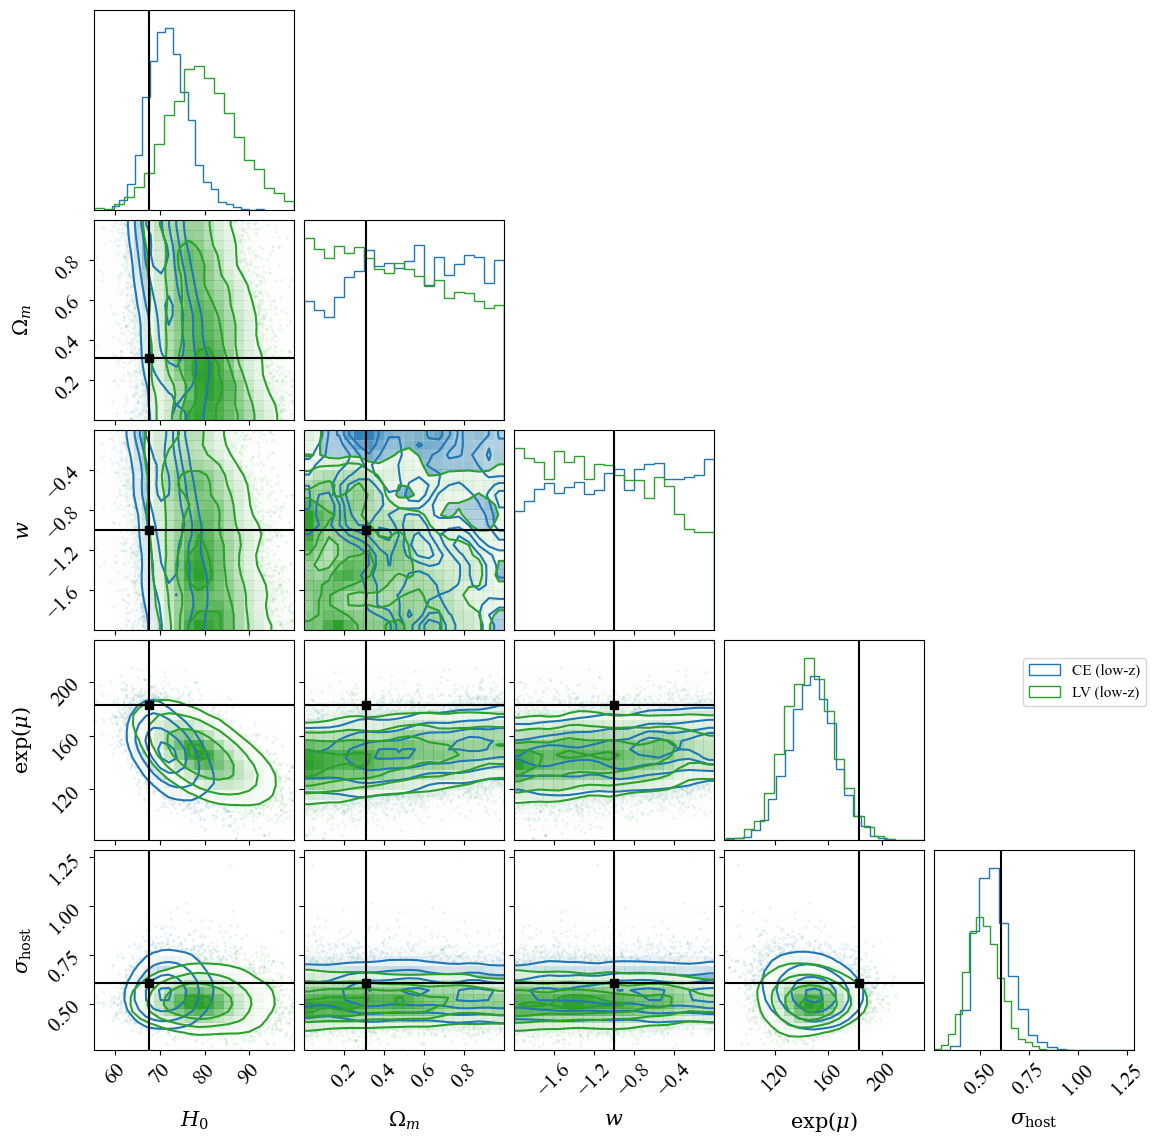

In [8]:
labels_all = [r"$H_0$", r"$\Omega_m$", r"$w$", r"$\exp(\mu)$", r"$\sigma_{\rm host}$"]

fig = corner.corner(
    lowz_ext_CE, labels=labels_all, color="tab:blue", smooth=True, label_kwargs={"fontsize": 15},
)
corner.corner(
    lowz_ext_LV, fig=fig, truths=[HUBBLE, OMEGA_MATTER, W_LAMBDA, EXP_MU, SIGMA_HOST], truth_color='black', color="tab:green", smooth=True
);

for ax in fig.get_axes():
    ax.tick_params(axis='both', labelsize=15)

plt.legend(['CE (low-z)', 'LV (low-z)'], loc='upper right', bbox_to_anchor=(0.1, 1., 1, 1), fontsize=11)
plt.savefig('./figures/MCMC_DM_ext_02.pdf')
plt.show()

------------------------------------------

**CE -- high-z vs low-z**

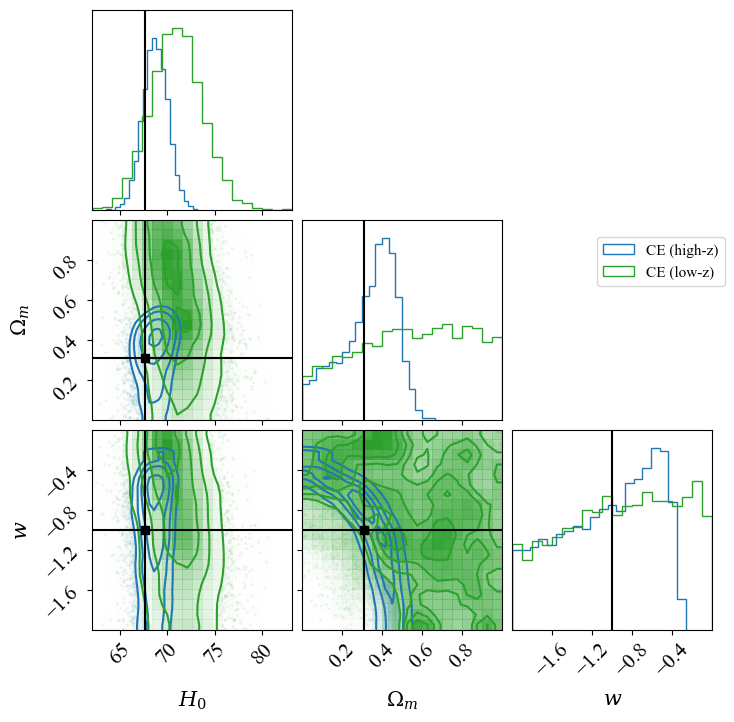

In [9]:
labels = [r"$H_0$", r"$\Omega_m$", r"$w$"]

fig = corner.corner(
    highz_diff, labels=labels, color="tab:blue", smooth=True, label_kwargs={"fontsize": 15},
)
corner.corner(
    lowz_diff_CE, fig=fig, truths=[HUBBLE, OMEGA_MATTER, W_LAMBDA], truth_color='black', color="tab:green", smooth=True
);

for ax in fig.get_axes():
    ax.tick_params(axis='both', labelsize=15)

plt.legend(['CE (high-z)', 'CE (low-z)'], loc='upper right', bbox_to_anchor=(0.1, 1., 1, 1), fontsize=11)
plt.show()

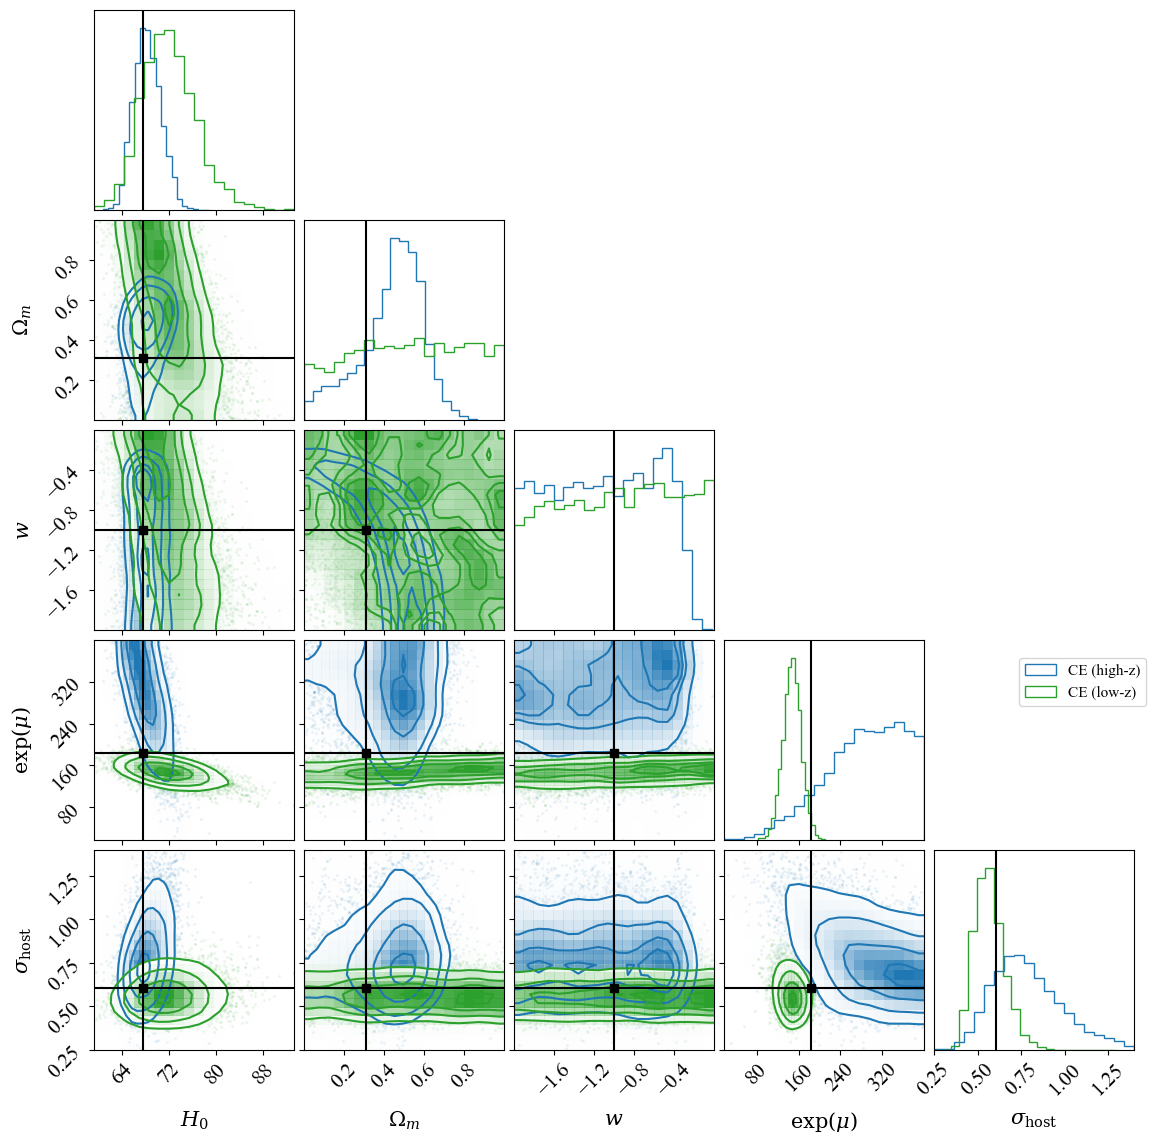

In [10]:
labels_all = [r"$H_0$", r"$\Omega_m$", r"$w$", r"$\exp(\mu)$", r"$\sigma_{\rm host}$"]

fig = corner.corner(
    highz_ext, labels=labels_all, color="tab:blue", smooth=True, label_kwargs={"fontsize": 15},
)
corner.corner(
    lowz_ext_CE, fig=fig, truths=[HUBBLE, OMEGA_MATTER, W_LAMBDA, EXP_MU, SIGMA_HOST], truth_color='black', color="tab:green", smooth=True
);

for ax in fig.get_axes():
    ax.tick_params(axis='both', labelsize=15)

plt.legend(['CE (high-z)', 'CE (low-z)'], loc='upper right', bbox_to_anchor=(0.1, 1., 1, 1), fontsize=11)
plt.show()

------------------------------------------

**CE -- high-z Macquart PDF vs log-normal PDF**

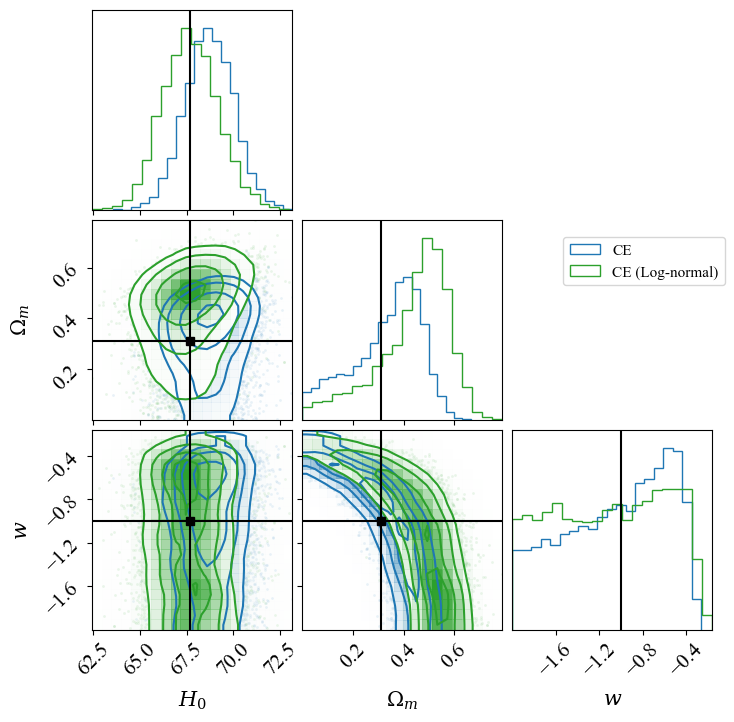

In [11]:
labels = [r"$H_0$", r"$\Omega_m$", r"$w$"]

fig = corner.corner(
    highz_diff, labels=labels, color="tab:blue", smooth=True, label_kwargs={"fontsize": 15},
)
corner.corner(
    highz_diff_ln, fig=fig, truths=[HUBBLE, OMEGA_MATTER, W_LAMBDA], truth_color='black', color="tab:green", smooth=True
);

for ax in fig.get_axes():
    ax.tick_params(axis='both', labelsize=15)

plt.legend(['CE', 'CE (Log-normal)'], loc='upper right', bbox_to_anchor=(0.1, 1., 1, 1), fontsize=11)
plt.savefig('./figures/MCMC_DM_diff_2.pdf')
plt.show()

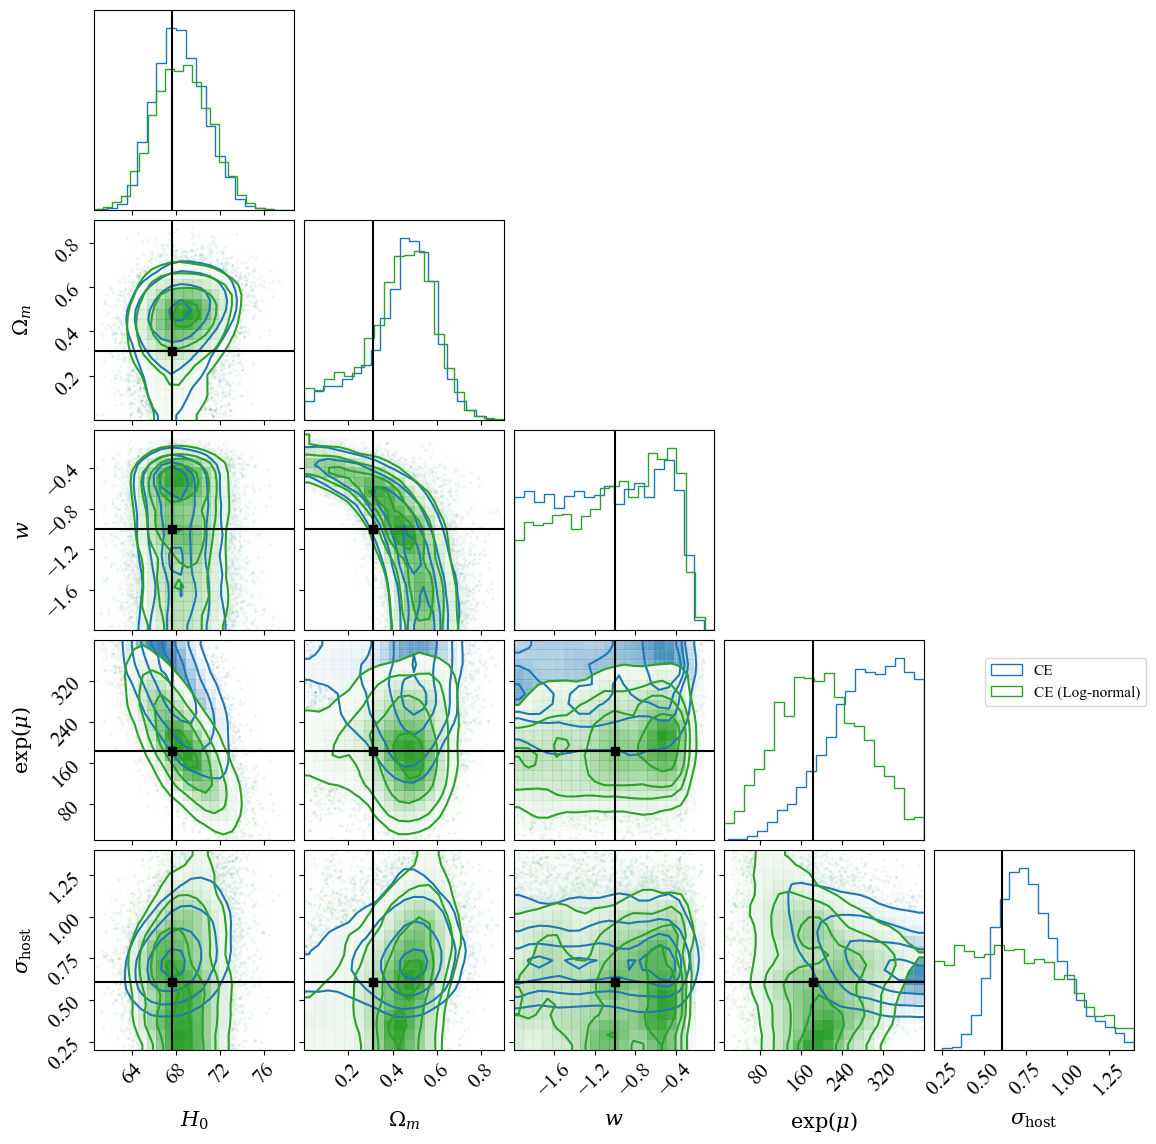

In [12]:
labels_all = [r"$H_0$", r"$\Omega_m$", r"$w$", r"$\exp(\mu)$", r"$\sigma_{\rm host}$"]

fig = corner.corner(
    highz_ext, labels=labels_all, color="tab:blue", smooth=True, label_kwargs={"fontsize": 15},
)
corner.corner(
    highz_ext_ln, fig=fig, truths=[HUBBLE, OMEGA_MATTER, W_LAMBDA, EXP_MU, SIGMA_HOST], truth_color='black', color="tab:green", smooth=True
);

for ax in fig.get_axes():
    ax.tick_params(axis='both', labelsize=15)

plt.legend(['CE', 'CE (Log-normal)'], loc='upper right', bbox_to_anchor=(0.1, 1., 1, 1), fontsize=11)
plt.savefig('./figures/MCMC_DM_ext_2.pdf')
plt.show()

data

In [13]:
import pickle
import os
from pathlib import Path

def read_data(DATA_FILE):
    if os.path.exists(DATA_FILE):
        # Load previously saved data
        print(f"Loading data from {DATA_FILE}...")
        with open(DATA_FILE, 'rb') as f:
            saved_data = pickle.load(f)
    
        # # events redshifts
        # z_centre = saved_data['z_centre']
        # # DL data
        # dL_obs_centre = saved_data['dL_obs_centre']
        # sigma_dL = saved_data['sigma_dL']
        # # DM_diff data
        # DM_diff_obs = saved_data['DM_diff_obs']
        # sigma_DM_diff = saved_data['sigma_DM_diff']
        # # DM_diff data from log-normal PDF
        # DM_diff_obs_ln = saved_data['DM_diff_obs_ln']
        # sigma_DM_diff_ln = saved_data['sigma_DM_diff_ln']
    
        # # DM_ext data
        # DM_ext_obs = saved_data['DM_ext_obs']
        # sigma_DM_ext = saved_data['sigma_DM_ext']
        # # DM_ext data from log-normal PDF
        # DM_ext_obs_ln = saved_data['DM_ext_obs_ln']
        # sigma_DM_ext_ln = saved_data['sigma_DM_ext_ln']
    
        # # Theoratical values (DM is the DM_diff)
        # dL_centre = saved_data['dL_centre']
        # DM_centre = saved_data['DM_centre']
    
        # S = saved_data['S']
        # Z_min = saved_data['Z_min']
        # Z_max = saved_data['Z_max']
        # REDSHIFT_METHOD = saved_data['REDSHIFT_METHOD']
    
        print(f"Successfully loaded events from saved data.")
        
        return saved_data
    
    else:
        print(f"No data file {DATA_FILE}, please check path or generate data.")
        sys.exit()
        
        return 0

In [14]:
data02 = read_data('./checkpoint/data_02.pkl')
data2 = read_data('./checkpoint/data_2.pkl')

Loading data from ./checkpoint/data_02.pkl...
Successfully loaded events from saved data.
Loading data from ./checkpoint/data_2.pkl...
Successfully loaded events from saved data.


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Text(0.5, 0, '$z$')

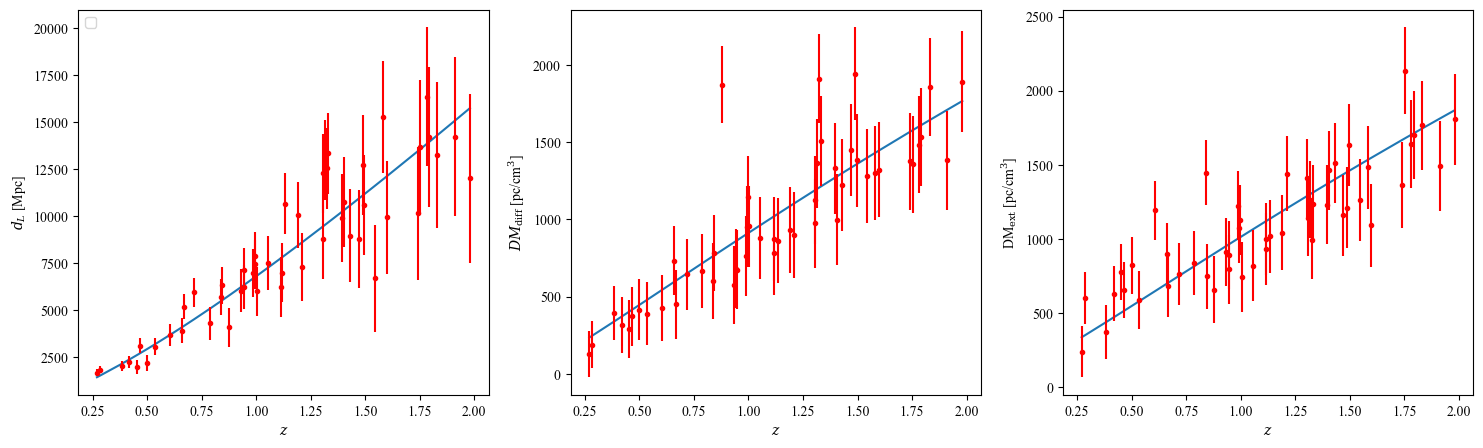

In [15]:
fig = plt.figure(figsize=(18, 5))
ax1 = fig.add_subplot(131)
ax2 = fig.add_subplot(132)
ax3 = fig.add_subplot(133)

ax1.plot(np.sort(data2['z_centre']), np.sort(data2['dL_centre']))
ax1.errorbar(data2['z_centre'], data2['dL_obs_centre'], yerr=data2['sigma_dL'], marker='o', ls='', ms=3, c='r')
ax1.set_ylabel(r'$d_{L}$ [Mpc]')
ax1.set_xlabel(r'$z$')
ax1.legend(loc='upper left')

ax2.plot(np.sort(data2['z_centre']), np.sort(data2['DM_centre']))
ax2.errorbar(data2['z_centre'], data2['DM_diff_obs'], yerr=data2['sigma_DM_diff'], marker='o', ls='', ms=3, c='r')
ax2.set_ylabel(r'$DM_{\rm diff}$ [pc/cm$^3$]')
ax2.set_xlabel(r'$z$')

ax3.plot(np.sort(data2['z_centre']), np.sort(data2['DM_centre'])+100)
ax3.errorbar(data2['z_centre'], data2['DM_ext_obs'], yerr=data2['sigma_DM_ext'], marker='o', ls='', ms=3, c='r')
ax3.set_ylabel(r'DM$_{\rm ext}$ [pc/cm$^3$]')
ax3.set_xlabel(r'$z$')

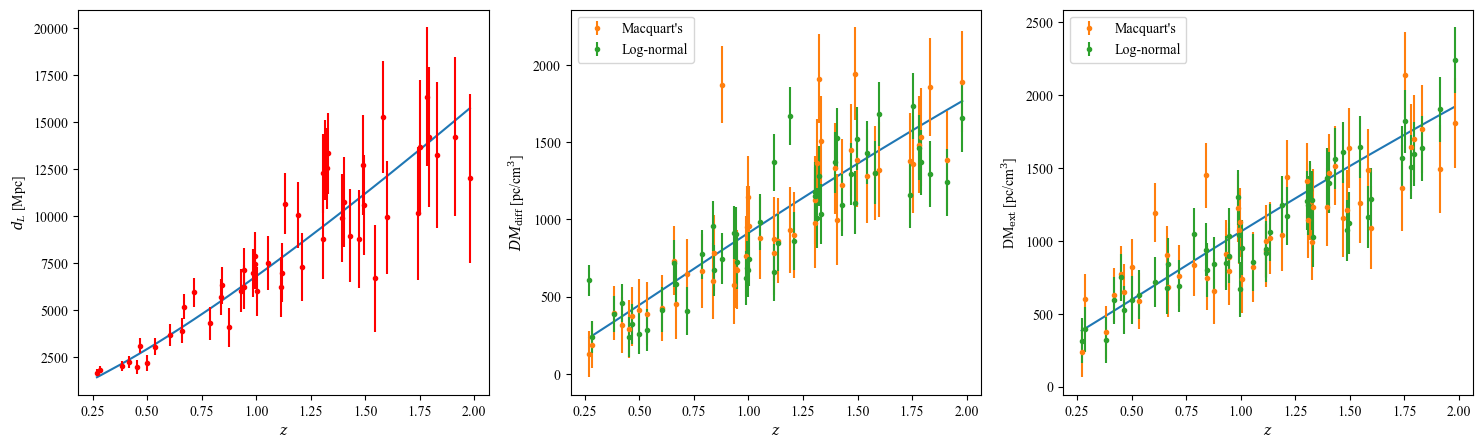

In [16]:
DATA_FIG="figures/events_DL_DM_redshift_distribution_2.png"

fig = plt.figure(figsize=(18, 5))
ax1 = fig.add_subplot(131)
ax2 = fig.add_subplot(132)
ax3 = fig.add_subplot(133)

ax1.plot(np.sort(data2['z_centre']), np.sort(data2['dL_centre']))
ax1.errorbar(data2['z_centre'], data2['dL_obs_centre'], yerr=data2['sigma_dL'], marker='o', ls='', ms=3, c='r')
ax1.set_ylabel(r'$d_{L}$ [Mpc]')
ax1.set_xlabel(r'$z$')
# ax1.legend(loc='upper left')

ax2.plot(np.sort(data2['z_centre']), np.sort(data2['DM_centre']))
ax2.errorbar(data2['z_centre'], data2['DM_diff_obs'], yerr=data2['sigma_DM_diff'], marker='o', ls='', ms=3, label='Macquart\'s')
ax2.errorbar(data2['z_centre'], data2['DM_diff_obs_ln'], yerr=data2['sigma_DM_diff_ln'], marker='o', ls='', ms=3, label='Log-normal')
ax2.set_ylabel(r'$DM_{\rm diff}$ [pc/cm$^3$]')
ax2.set_xlabel(r'$z$')
ax2.legend(loc='upper left')

ax3.plot(np.sort(data2['z_centre']), np.sort(data2['DM_centre'])+150)
ax3.errorbar(data2['z_centre'], data2['DM_ext_obs'], yerr=data2['sigma_DM_ext'], marker='o', ls='', ms=3, label='Macquart\'s')
ax3.errorbar(data2['z_centre'], data2['DM_ext_obs_ln'], yerr=data2['sigma_DM_ext_ln'], marker='o', ls='', ms=3, label='Log-normal')
ax3.set_ylabel(r'DM$_{\rm ext}$ [pc/cm$^3$]')
ax3.set_xlabel(r'$z$')
ax3.legend(loc='upper left')

Path(DATA_FIG).parent.mkdir(parents=True, exist_ok=True)
plt.savefig(DATA_FIG)
# plt.tight_layout()

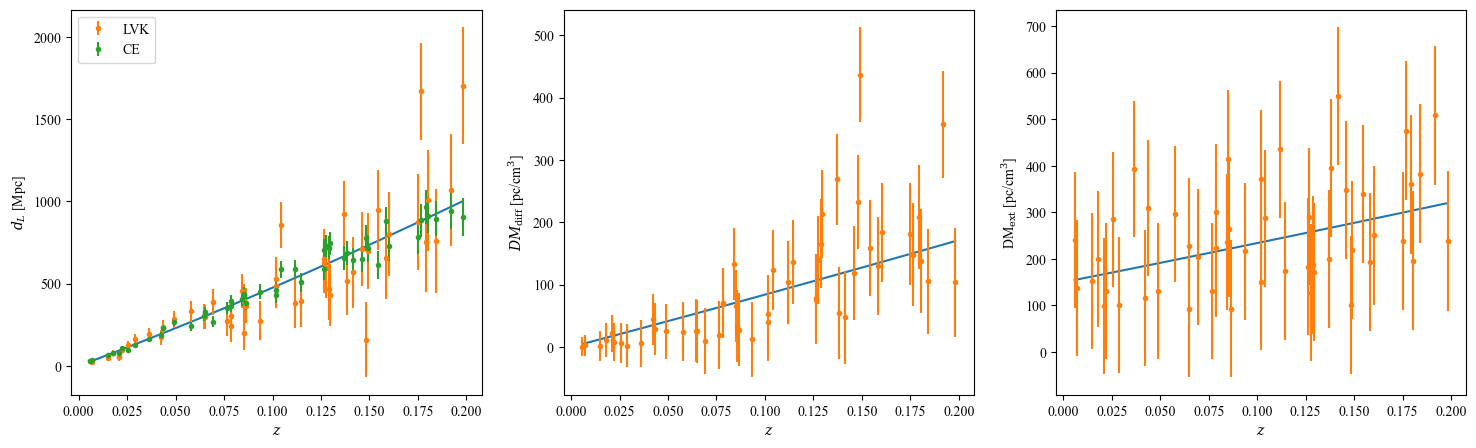

In [17]:
DATA_FIG="figures/events_DL_DM_redshift_distribution_02.png"

fig = plt.figure(figsize=(18, 5))
ax1 = fig.add_subplot(131)
ax2 = fig.add_subplot(132)
ax3 = fig.add_subplot(133)

ax1.plot(np.sort(data02['z_centre']), np.sort(data02['dL_centre']))
ax1.errorbar(data02['z_centre'], data02['dL_obs_centre_LVK'], yerr=data02['sigma_dL_LVK'], marker='o', ls='', ms=3, label='LVK')
ax1.errorbar(data02['z_centre'], data02['dL_obs_centre_CE'], yerr=data02['sigma_dL_CE'], marker='o', ls='', ms=3, label='CE')
ax1.set_ylabel(r'$d_{L}$ [Mpc]')
ax1.set_xlabel(r'$z$')
ax1.legend(loc='upper left')

ax2.plot(np.sort(data02['z_centre']), np.sort(data02['DM_centre']))
ax2.errorbar(data02['z_centre'], data02['DM_diff_obs'], yerr=data02['sigma_DM_diff'], marker='o', ls='', ms=3)
ax2.set_ylabel(r'$DM_{\rm diff}$ [pc/cm$^3$]')
ax2.set_xlabel(r'$z$')
# ax2.legend(loc='upper left')

ax3.plot(np.sort(data02['z_centre']), np.sort(data02['DM_centre'])+150)
ax3.errorbar(data02['z_centre'], data02['DM_ext_obs'], yerr=data02['sigma_DM_ext'], marker='o', ls='', ms=3)
ax3.set_ylabel(r'DM$_{\rm ext}$ [pc/cm$^3$]')
ax3.set_xlabel(r'$z$')
# ax3.legend(loc='upper left')

Path(DATA_FIG).parent.mkdir(parents=True, exist_ok=True)
plt.savefig(DATA_FIG)
# plt.tight_layout()